# 🏥 Diabetes Risk Prediction Project
#### Author: Dominic Colucci


### This project builds a machine learning model to predict diabetes risk based on health indicators.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Inline plotting
%matplotlib inline



### Load Dataset

In [3]:
# Load the CSV using a raw string (r"") to handle backslashes correctly
df = pd.read_csv("diabetes_data.csv")
# Preview the first few rows
df.head()


,Age,FamilyHistory,RapidWeightLoss,FrequentThirst,FrequentUrination,Fatigue,BlurredVision,IncreasedHunger,RecentIllness,DryMouthOrSkin,T1DOutcome
0,37.275872,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1,60.735505,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
2,52.894560,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,9.098667,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
4,25.663839,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0


### Exploratory Data Analysis (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                5000 non-null   float64
 1   FamilyHistory      5000 non-null   float64
 2   RapidWeightLoss    5000 non-null   float64
 3   FrequentThirst     5000 non-null   float64
 4   FrequentUrination  5000 non-null   float64
 5   Fatigue            5000 non-null   float64
 6   BlurredVision      5000 non-null   float64
 7   IncreasedHunger    5000 non-null   float64
 8   RecentIllness      5000 non-null   float64
 9   DryMouthOrSkin     5000 non-null   float64
 10  T1DOutcome         5000 non-null   float64
dtypes: float64(11)
memory usage: 429.8 KB
Age                  0
FamilyHistory        0
RapidWeightLoss      0
FrequentThirst       0
FrequentUrination    0
Fatigue              0
BlurredVision        0
IncreasedHunger      0
RecentIllness        0
DryMouthOrSkin     

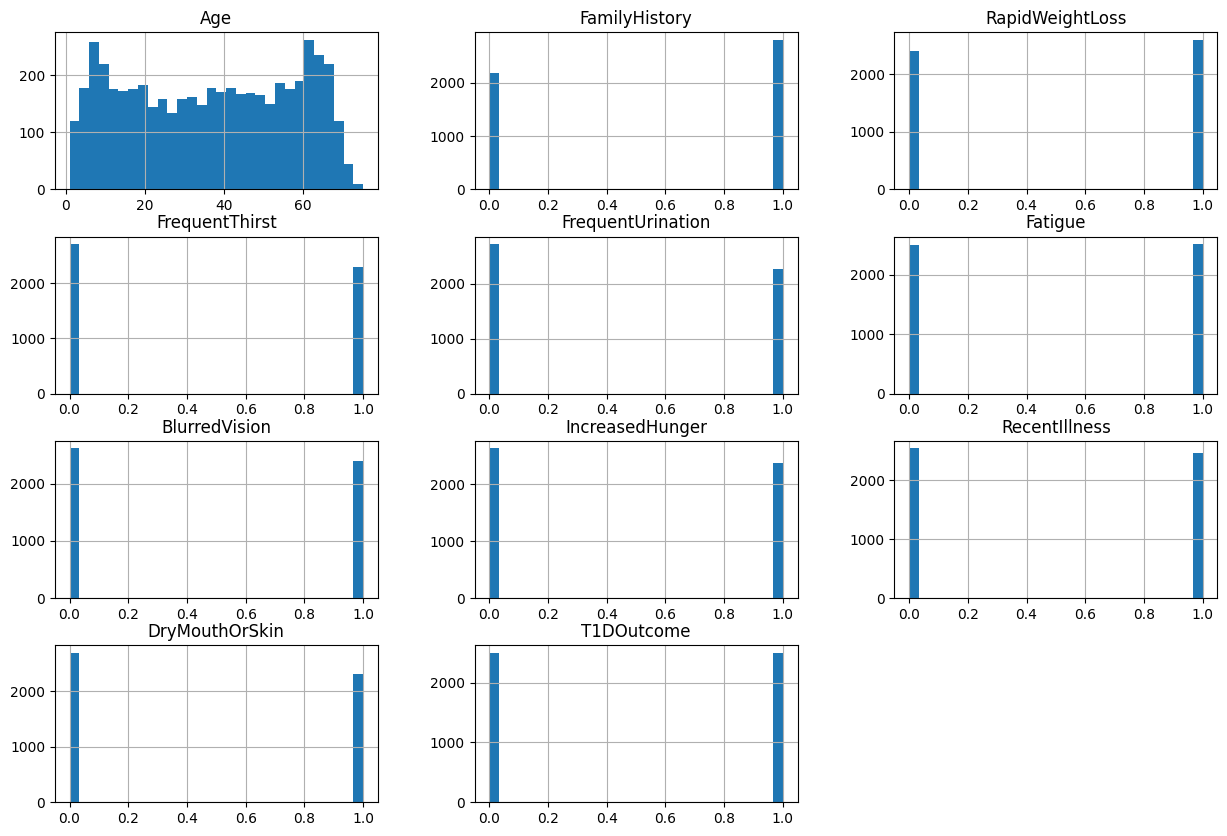

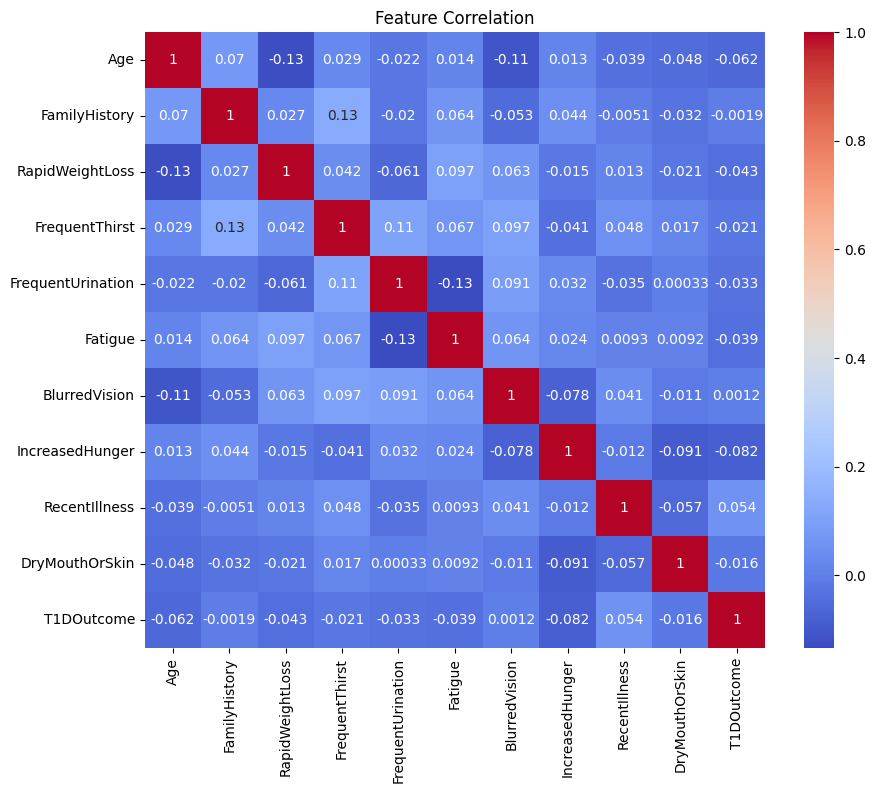

In [4]:
df.info()

# Check for missing or suspicious values (zeros)
print(df.isnull().sum())
print((df == 0).sum())

# Quick histograms to visualize data distributions
df.hist(bins=30, figsize=(15,10))
plt.show()


# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()


### Data Pre-Processing

In [5]:
# Handle missing values if any
df.fillna(df.median(), inplace=True)  # or choose smarter imputation later

# Select features and target
features = [
    'Age', 'FamilyHistory', 'RapidWeightLoss', 'FrequentThirst', 'FrequentUrination',
    'Fatigue', 'BlurredVision', 'IncreasedHunger', 'RecentIllness', 'DryMouthOrSkin'
]
X = df[features]
y = df['T1DOutcome']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale all features after split (including Age)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Training Models

In [6]:
# Baseline Model - Logistic Regression

# Train
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Evaluate
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

# --------------------------------------------------------------------------------------------

# Second Model - Random Forest

# Train
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Random Forest:")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.55      0.50      0.53       501
         1.0       0.54      0.59      0.57       499

    accuracy                           0.55      1000
   macro avg       0.55      0.55      0.55      1000
weighted avg       0.55      0.55      0.55      1000

[[252 249]
 [203 296]]
Random Forest:
              precision    recall  f1-score   support

         0.0       0.88      0.89      0.88       501
         1.0       0.89      0.87      0.88       499

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000

[[445  56]
 [ 63 436]]


### Save trained model and scaler for future use

In [7]:
import joblib

# Save model and scaler to disk
joblib.dump(rf_model, 't1d_rf_model.pkl')
joblib.dump(scaler, 't1d_scaler.pkl')

print("Random Forest model and scaler saved.")


Random Forest model and scaler saved.


### Model Comparison: ROC Curves

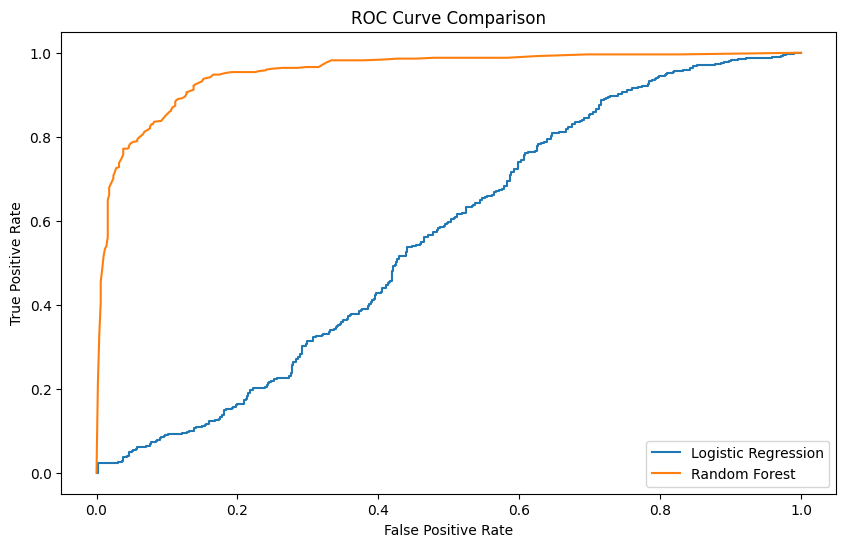

In [8]:
# Predict probabilities
y_pred_proba_lr = lr_model.predict_proba(X_test)[:,1]
y_pred_proba_rf = rf_model.predict_proba(X_test)[:,1]

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(10,6))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

### Model Explainability - LIME

In [9]:
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

# LIME explainer setup for the random forest model
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=features,
    class_names=['No T1D', 'T1D'],
    mode='classification'
)

# Explain one prediction
i = 0  # Pick any test index you'd like
lime_exp = lime_explainer.explain_instance(X_test[i], rf_model.predict_proba)

# Show explanation in a Jupyter notebook (or save if running as .py)
lime_exp.show_in_notebook()



### Load Saved Model & Predict on New Data

In [10]:
import joblib
import numpy as np

# Load the saved model and scaler
model = joblib.load('t1d_rf_model.pkl')
scaler = joblib.load('t1d_scaler.pkl')

# Example new patient (in the same order as training features)
new_patient = np.array([[40, 1, 0, 1, 1, 1, 0, 0, 0, 1]])

# Scale input
new_patient_scaled = scaler.transform(new_patient)

# Predict risk probability
risk_score = model.predict_proba(new_patient_scaled)[0][1]
print(f"Predicted T1D Risk: {risk_score:.2f}")

Predicted T1D Risk: 0.86


C:\Users\domin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
